Давайте познакомимся с одним из способов выделения трендовой и сезонной компонент ряда и визуального анализа шума.

In [38]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib import pyplot
from statsmodels.tsa.stattools import adfuller

In [24]:
df = pd.read_csv('data/train.csv') # считываем датасет
display(df)
df = df[df.store_nbr==25].groupby("date")['unit_sales'].sum().reset_index()
df.head()

C:\Users\ekash\AppData\Local\Temp\ipykernel_31588\2204645120.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train.csv') # считываем датасет


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


,date,unit_sales
0,2013-01-01,2511.619
1,2013-01-02,5316.224
2,2013-01-03,4442.913
3,2013-01-04,4844.354
4,2013-01-05,5817.526


In [ ]:
# Check the records time intervals
df.index.to_series().diff().value_counts()



date
1 days     1612
2 days        4
67 days       1
Name: count, dtype: int64

In [13]:
# приводим индексы к стандарту pd.Datetime, чтобы потом это можно было скормить seasonal_decompose
df = df.set_index(pd.DatetimeIndex(df['date']))
df.head() # смотрим на результат

,date,unit_sales
date,,
2013-01-01,2013-01-01,2511.619
2013-01-02,2013-01-02,5316.224
2013-01-03,2013-01-03,4442.913
2013-01-04,2013-01-04,4844.354
2013-01-05,2013-01-05,5817.526


In [26]:
 # замечаем, что т.к. у нас теперь есть индекс Month, нам больше не нужен столбец Month, который его дублирует
df.drop(['date'], axis = 1, inplace = True)
df.head() # снова проверяем, что все в порядке. вообще проверять данные на каждом шаге кода - хорошая привычка

,unit_sales
0,2511.619
1,5316.224
2,4442.913
3,4844.354
4,5817.526


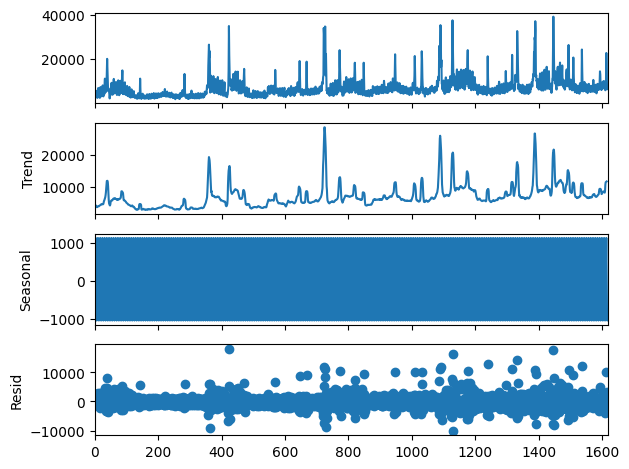

In [27]:
# применяем seasonal_decompose
# эта функция разложит ряд на трендовую, сезонную и шумовую составляющие
decomposition = seasonal_decompose(df, model='additive', period=7) 
decomposition.plot()
pyplot.show() # любуемся результатом

In [28]:
trend_part = decomposition.trend # отдельно трендовая составляющаяя
seasonal_part = decomposition.seasonal # отдельно сезонная составляющаяя
residual_part = decomposition.resid # отдельно шум: то, что осталось

In [29]:
# посмотрим повнимательнее на остатки в начале ряда
residual_part.head()

0            NaN
1            NaN
2            NaN
3    -411.495279
4    1339.348133
Name: resid, dtype: float64

In [30]:
# посмотрим повнимательнее на остатки в конце ряда
residual_part.tail()

1613    10073.126293
1614     3122.839133
1615             NaN
1616             NaN
1617             NaN
Name: resid, dtype: float64

In [31]:
# в конце и в начале стоят значения NaN. Это связано с особенностями алгоритма seasonal_decompose
# если мы хотим далее анализировать остатки, необходимо избавиться от этих некорректных значений
residual_part = residual_part.dropna()
residual_part.head()

3    -411.495279
4    1339.348133
5       9.978060
6     154.174368
7      13.948264
Name: resid, dtype: float64

In [37]:
# 1. Сколько элементов содержит исходный датасет?
int_length = len(decomposition.observed)
print(f'Исходный датасет содержит: {int_length} элементов')

# 2. Сколько элементов содержит шумовая часть?
residual_part = decomposition.resid
print(f'Шумовая часть содержит: {len(residual_part)} элементов')

# 3. Сколько числовых элементов содержит шумовая часть?
res_dig_count = residual_part.count()
print(f'Шумовая часть содержит: {res_dig_count} числовых элементов')

# 4. Сколько элементов содержит сезонная часть?
seasonal_part = decomposition.seasonal
print(f'Сезонная часть содержит: {len(seasonal_part)} элементов')

# 5. Сколько числовых элементов содержит трендовая часть?
trend_part = decomposition.trend
trend_dig_count = trend_part.count()
print(f'Трендовая часть содержит: {trend_dig_count} числовых элементов')



Исходный датасет содержит: 1618 элементов
Шумовая часть содержит: 1618 элементов
Шумовая часть содержит: 1612 числовых элементов
Сезонная часть содержит: 1618 элементов
Трендовая часть содержит: 1612 числовых элементов


In [42]:
# Use your series (drop NaN if decomposition created them)
series = df["unit_sales"].dropna()

adf_result = adfuller(series, result_object=False)

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Used lags:", adf_result[2])
print("Number of observations:", adf_result[3])
print("Critical values:", adf_result[4])


ADF statistic: -4.858992665318185
p-value: 4.188394192907693e-05
Used lags: 25
Number of observations: 1592
Critical values: {'1%': -3.4344642432857992, '5%': -2.8633571955690647, '10%': -2.5677374399794197}


## Комментарий к результатам теста Дики–Фуллера

Результаты теста:

ADF statistic: −4.85899

p-value: 0.00004188

Used lags: 25

### Number of observations: 1592

Critical values:

1%: −3.43446

5%: −2.86336

10%: −2.56774

### Интерпретация
Тест Дики–Фуллера проверяет гипотезу:

H₀ (нулевая гипотеза): ряд нестационарный, содержит единичный корень.

H₁ (альтернативная гипотеза): ряд стационарный.


### Основные выводы
ADF statistic = −4.86  
Значение статистики значительно меньше всех критических значений (−3.43, −2.86, −2.56).
Это означает, что мы отклоняем нулевую гипотезу.

p-value = 0.00004188  
p‑value намного меньше порога 0.05 и даже 0.01.
Это подтверждает, что ряд стационарный с очень высокой степенью уверенности.

Использовано лагов: 25  
Тест автоматически подобрал количество лагов для устранения автокорреляции.


Число наблюдений: 1592  
После удаления лагов осталось достаточно данных для корректного теста.

### Итоговый вывод
Временной ряд является стационарным.  
Он не содержит единичного корня, не требует дифференцирования и может использоваться в моделях типа ARIMA(p,0,q) без предварительного преобразования.

## Продолжаем выполнять проект в Jupyter Notebook.

Используем временной ряд для одного магазина (используем из прошлого задания).

Создаем функцию скользящего среднего c окном 5.

Создаем функцию скользящего квадратического отклонения c окном 5. 

In [57]:
def rolling_mean(df):
    return df["unit_sales"].rolling(window=5).mean()

def rolling_std(df):
    return df["unit_sales"].rolling(window=5).std()


In [58]:
df['rolling_mean'] = rolling_mean(df)
df["rolling_std"] = rolling_std(df)

display(df)

,unit_sales,rolling_mean,rolling_std
0,2511.619,NaN,NaN
1,5316.224,NaN,NaN
2,4442.913,NaN,NaN
3,4844.354,NaN,NaN
4,5817.526,4586.5272,1268.873437
...,...,...,...
1613,22800.841,11368.5020,6654.095169
1614,15090.753,12881.1830,6418.091607
1615,8570.598,13390.2968,5810.462774
1616,8244.854,13097.6960,6073.159403


## Строим линии Боллинджера

Строим так называемые линии Боллинджера с окном в 30.
Добавляем к скользящему среднему скользящее стандартное отклонение, умноженное на три — верхняя линия Боллинджера.
Отнимаем от скользящего среднего скользящее стандартное отклонение, умноженное на три — нижняя линия Боллинджера.
Строим график.

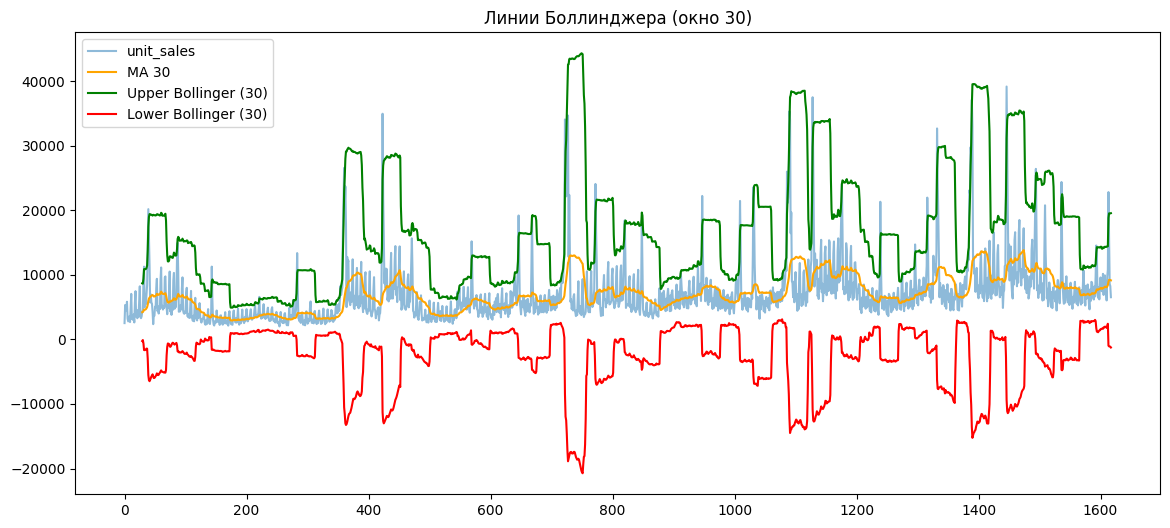

In [59]:
# Скользящее среднее с окном 30
rolling_mean_30 = df["unit_sales"].rolling(window=30).mean()

# Скользящее стандартное отклонение с окном 30
rolling_std_30 = df["unit_sales"].rolling(window=30).std()

# Линии Боллинджера
upper_band = rolling_mean_30 + 3 * rolling_std_30
lower_band = rolling_mean_30 - 3 * rolling_std_30

# График
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df["unit_sales"], label="unit_sales", alpha=0.5)
plt.plot(rolling_mean_30, label="MA 30", color="orange")
plt.plot(upper_band, label="Upper Bollinger (30)", color="green")
plt.plot(lower_band, label="Lower Bollinger (30)", color="red")
plt.legend()
plt.title("Линии Боллинджера (окно 30)")
plt.show()


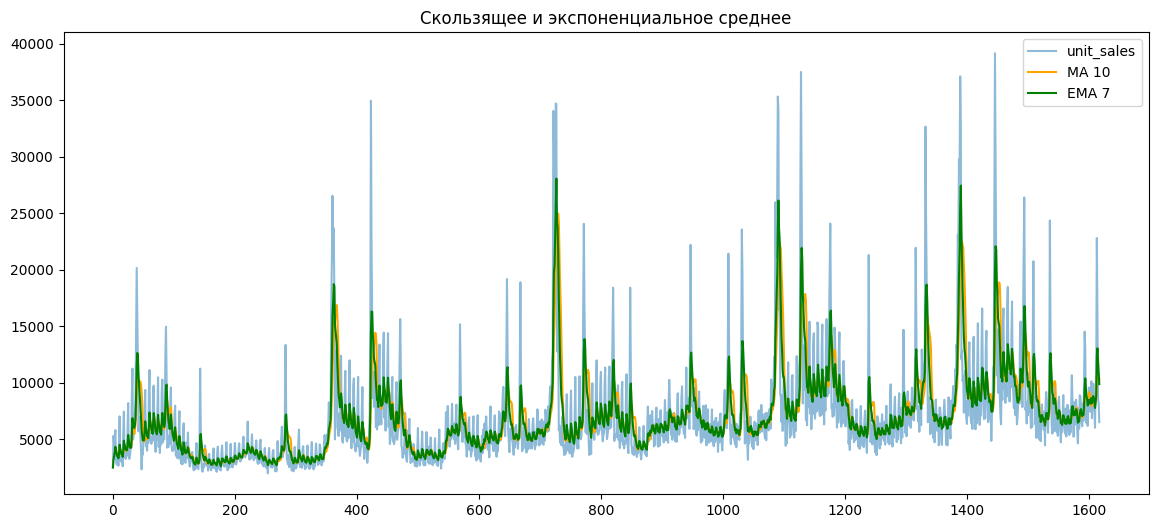

In [60]:
# Оконное среднее с окном 10
rolling_mean_10 = df["unit_sales"].rolling(window=10).mean()

# Экспоненциальное среднее (EMA) с окном 7
ema_7 = df["unit_sales"].ewm(span=7, adjust=False).mean()

# Отображаем их на отдельном графике
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df["unit_sales"], label="unit_sales", alpha=0.5)
plt.plot(rolling_mean_10, label="MA 10", color="orange")
plt.plot(ema_7, label="EMA 7", color="green")
plt.legend()
plt.title("Скользящее и экспоненциальное среднее")
plt.show()



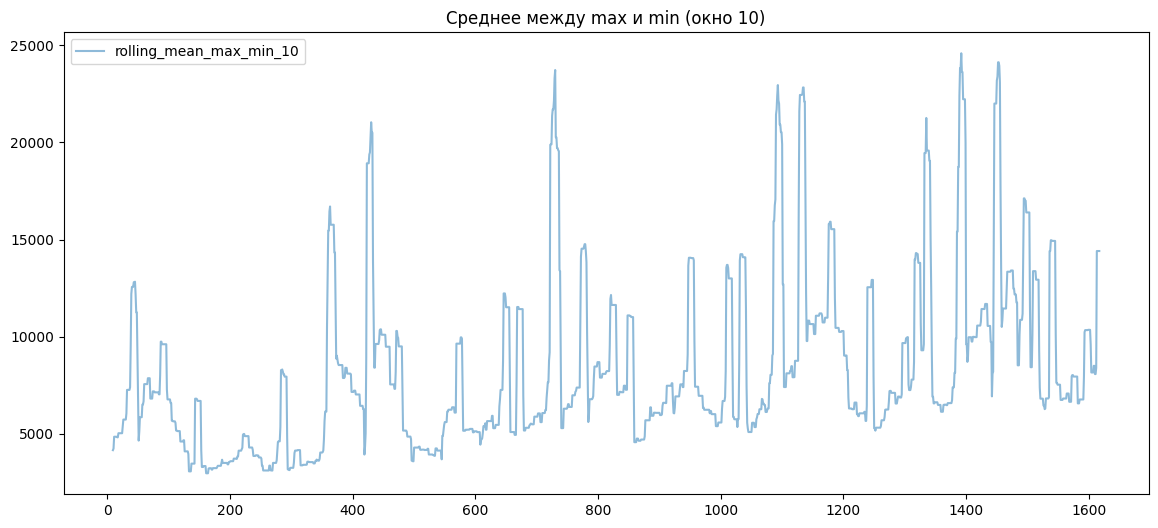

In [61]:
# Создаем скользящую функцию: среднее между max и min (окно 10)
def rolling_mean_max_min(df, field_name, window=10):
    return (df[field_name].rolling(window=window).max() + df[field_name].rolling(window=window).min()) / 2

rolling_mean_max_min_10 = rolling_mean_max_min(df, field_name="unit_sales", window=10)

# Строим график rolling_mean_max_min_10
plt.figure(figsize=(14,6))
plt.plot(rolling_mean_max_min_10, label="rolling_mean_max_min_10", alpha=0.5)
plt.legend()
plt.title("Среднее между max и min (окно 10)")
plt.show()

In [62]:
# Пересечения MA50 и EMA10

# Скользящее среднее 50
ma50 = df["unit_sales"].rolling(window=50).mean()

# Экспоненциальное среднее 10
ema10 = df["unit_sales"].ewm(span=10, adjust=False).mean()

# Разность
diff_series = ma50 - ema10
sign_series = np.sign(diff_series)                          # Знак разности
cross_points = sign_series.diff()                           # Дифференцирование знака
cross_indices = cross_points[cross_points != 0].index       # Точки пересечения (где diff ≠ 0)
cross_indices

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       1499, 1509, 1512, 1536, 1540, 1544, 1546, 1573, 1575, 1586],
      dtype='int64', length=178)

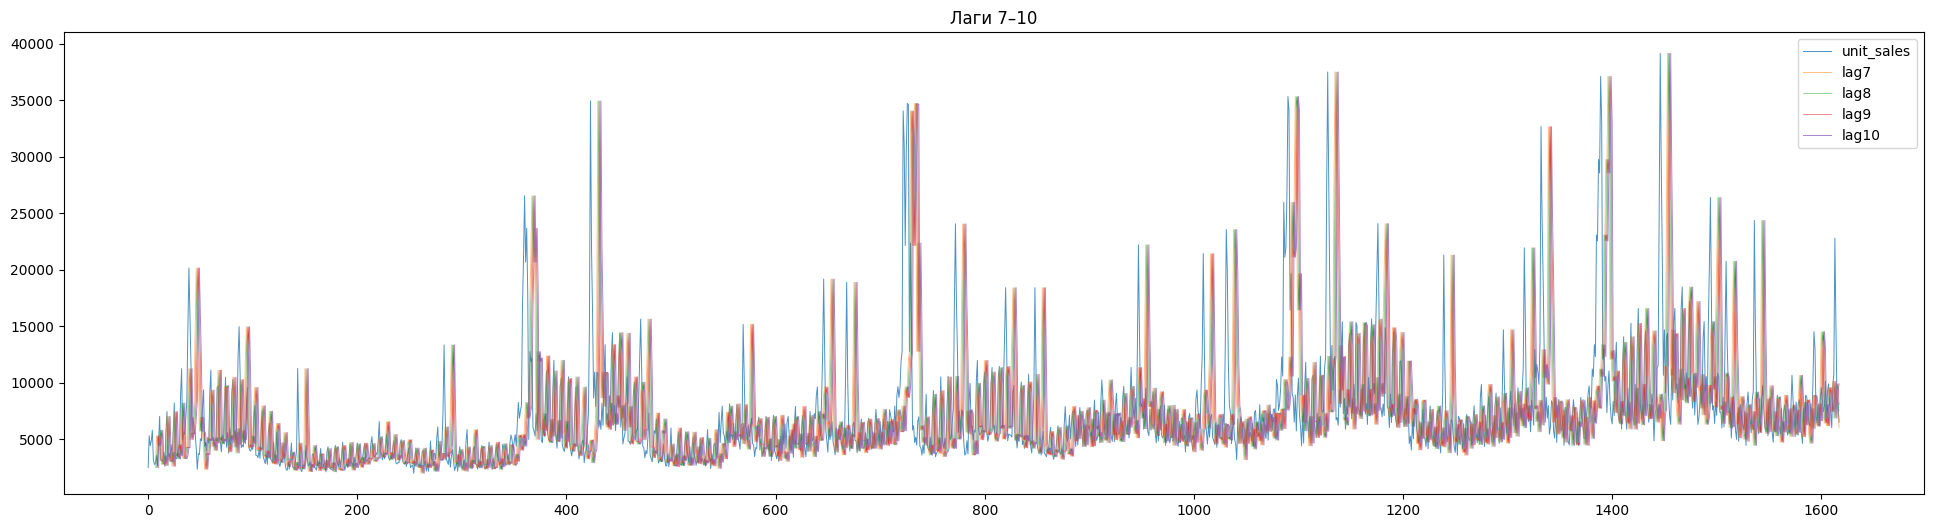

In [87]:
# Лаги 7–10 и график

df["lag7"]  = df["unit_sales"].shift(7)
df["lag8"]  = df["unit_sales"].shift(8)
df["lag9"]  = df["unit_sales"].shift(9)
df["lag10"] = df["unit_sales"].shift(10)

# График лагов
lw = 0.7   # толщину линий

plt.figure(figsize=(24,6))

plt.plot(df["unit_sales"], label="unit_sales", alpha=0.8, lw=lw)
plt.plot(df["lag7"], label="lag7", alpha=0.5, lw=lw)
plt.plot(df["lag8"], label="lag8", alpha=0.8,  lw=lw-0.3)
plt.plot(df["lag9"], label="lag9", alpha=0.9,  lw=lw-0.3)
plt.plot(df["lag10"], label="lag10", alpha=0.8, lw=lw)

plt.title("Лаги 7–10")
plt.legend()
plt.show()

